# STARmap_PrelimbicArea

In [1]:
import warnings
warnings.filterwarnings("ignore")
import MENDER
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import *
import time

In [2]:
## load the data using pysodb, please install pysodb in advance [https://pysodb.readthedocs.io/en/latest/]

import pysodb
sodb = pysodb.SODB()
adata_dict = sodb.load_dataset('Dataset11_MS_raw')
adata = list(adata_dict.values())[0]

load experiment[Dataset11] in dataset[Dataset11_MS_raw]


In [3]:
adata_raw = adata.copy()

In [4]:
batch_obs = 'slice_id'
gt_obs = 'gt'

In [5]:
# input parameters of MENDER
scale = 6
# the default radius is 15 um, the unit of spatial coordinate of this dataset is 0.1 um
radius = 150 

# estimate number of domains
n_cls = np.unique(adata.obs[gt_obs]).shape[0]


# record running time 
time_st = time.time()


adata = adata_raw.copy()


# main body of MENDER
msm = MENDER.MENDER(
    adata,
    batch_obs = batch_obs, 
    # determine which cell state to use
    # we use the cell state got by Leiden
    ct_obs='ct'
)


# set the MENDER parameters


msm.prepare()
msm.set_MENDER_para(
    # default of n_scales is 6
    n_scales=scale, 
    
    # for single cell data, nn_mode is set to 'radius' 
    nn_mode='radius',
    
    # default of n_scales is 15 um (see the manuscript for the analysis).
    # MENDER also provide a function 'estimate_radius' for estimating the radius
    nn_para=radius, 

)
# construct the context representation
msm.run_representation_mp(
    200
    # the number of processings
)

# set the spatial clustering parameter
# positive values for the expected number of domains
# negative values for the clustering resolution
msm.run_clustering_normal(n_cls)

time_ed = time.time()
time_cost = time_ed-time_st




default number of process is 200
total batch: 3, running batch BZ14
total batch: 3, running batch BZ5
total batch: 3, running batch BZ9
scale 0, median #cells per radius (r=150): 1.0
scale 0, median #cells per radius (r=150): 1.0
scale 0, median #cells per radius (r=150): 1.0
scale 1, median #cells per radius (r=150): 3.0
scale 1, median #cells per radius (r=150):scale 1, median #cells per radius (r=150):  3.03.0

scale 2, median #cells per radius (r=150): 6.0
scale 2, median #cells per radius (r=150): 5.0
scale 2, median #cells per radius (r=150): 5.0
scale 3, median #cells per radius (r=150): 8.0
scale 3, median #cells per radius (r=150): 6.0
scale 3, median #cells per radius (r=150): 7.0
scale 4, median #cells per radius (r=150): 10.0
scale 4, median #cells per radius (r=150): 8.0
scale 4, median #cells per radius (r=150): 8.0
scale 5, median #cells per radius (r=150): 12.0
scale 5, median #cells per radius (r=150): 9.0
scale 5, median #cells per radius (r=150): 10.0
searching resol

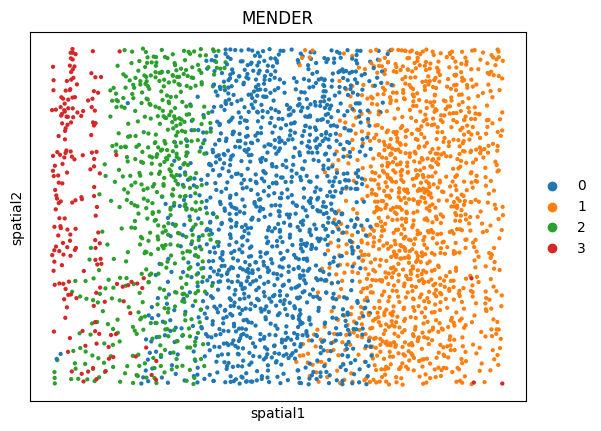

MENDER prediction


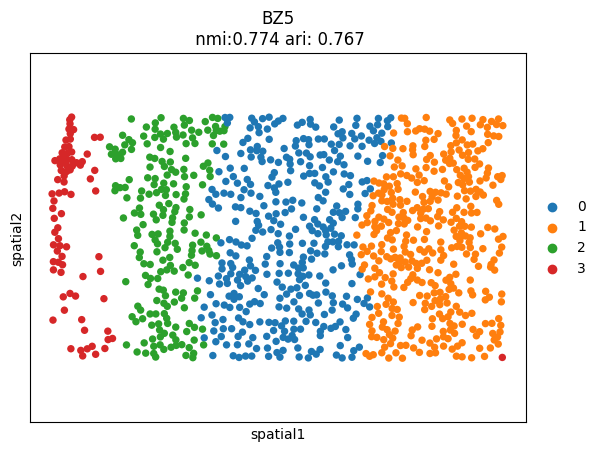

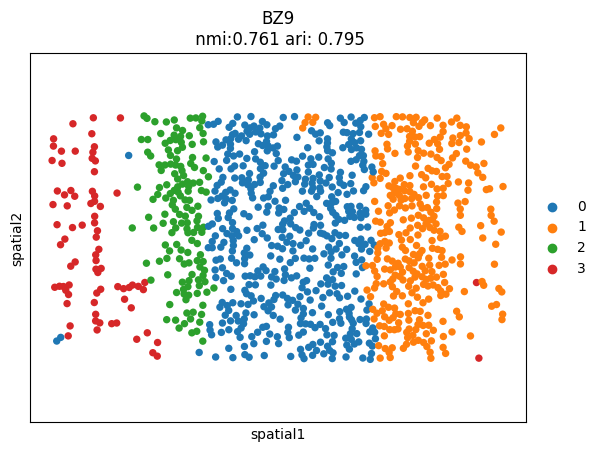

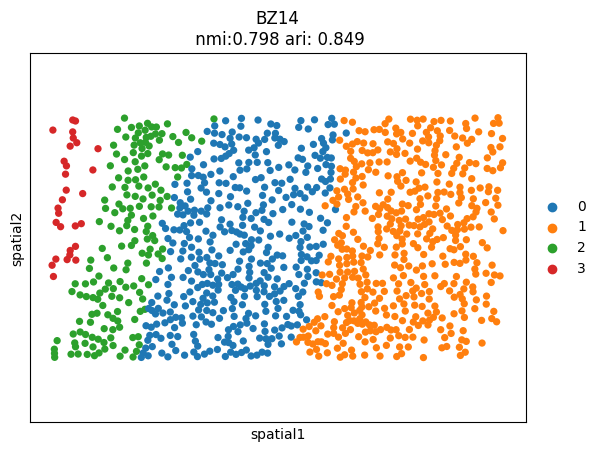

In [6]:
# the plot function has two parameters
# obs: the observation to plot
# gt_obs: the ground truth observation to compute NMI and ARI, can be set to None if not available
msm.output_cluster_all(obs='MENDER',obs_gt=gt_obs)
print('MENDER prediction')

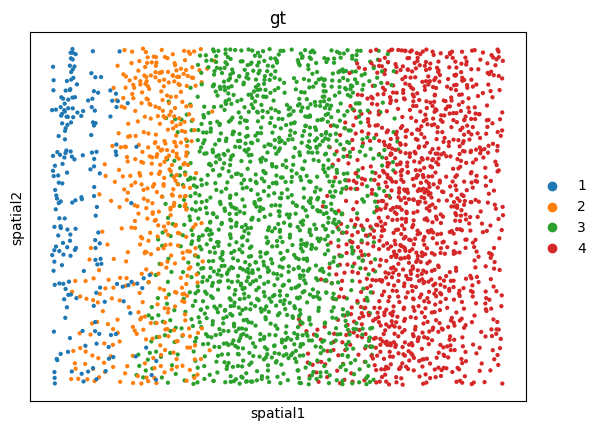

ground truth


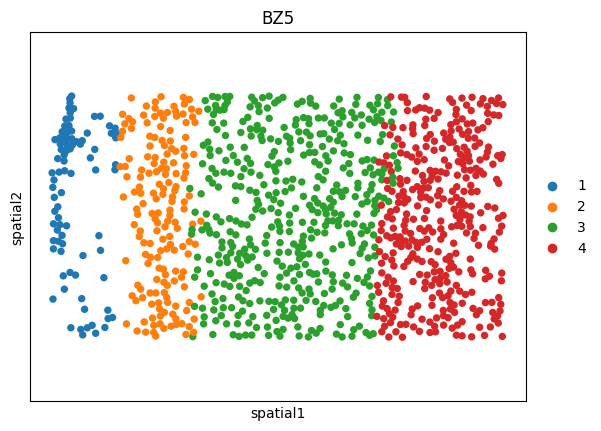

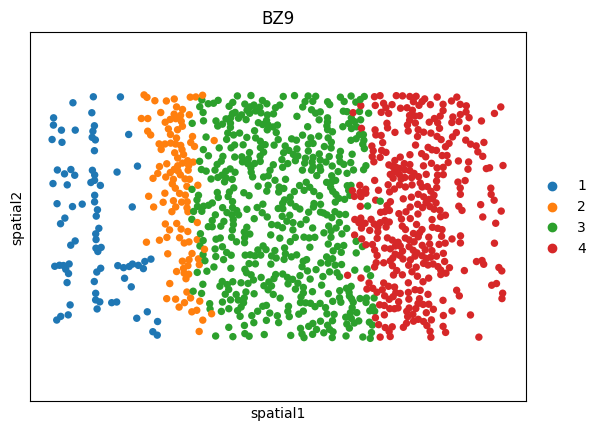

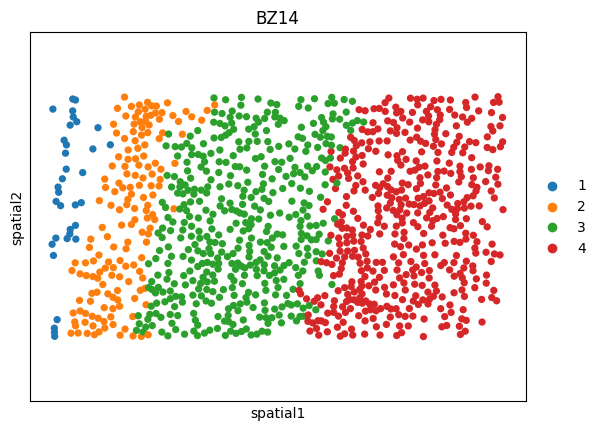

In [7]:
# the plot function has two parameters
# obs: the observation to plot
# gt_obs: the ground truth observation to compute NMI and ARI, can be set to None if not available

msm.output_cluster_all(obs=gt_obs,obs_gt=None)
print('ground truth')

In [8]:
print(f'running time: {time_cost} s')

running time: 8.69901728630066 s
